In [ ]:
import pandas as pd
import numpy as np
import json
import unicodedata
from tqdm import tqdm
import torch
import torch.nn as nn
import regex as re


In [ ]:

def load_phoneme_vectors(csv_path):
    df = pd.read_csv(csv_path)

    phoneme_col = df.columns[0]
    feature_cols = df.columns[1:]

    phoneme2vec = {}
    for _, row in df.iterrows():
        phoneme = row[phoneme_col]
        vector = row[feature_cols].astype(int).values
        phoneme2vec[phoneme] = vector

    feature_dim = len(feature_cols)
    return phoneme2vec, feature_dim


In [ ]:
phoneme2vec, FEATURE_DIM = load_phoneme_vectors("/content/drive/MyDrive/Sanskrit NLP/sanskrit_phoneme_vectors (1).csv")


In [ ]:
def load_words(txt_path):
    with open(txt_path, encoding="utf-8") as f:
        words = [line.strip() for line in f if line.strip()]
    return words

words = load_words("/content/drive/MyDrive/Sanskrit NLP/161655_RV_Terms.txt")
print("Total words:", len(words))

Total words: 161655


In [ ]:
def normalize_word(word):
    word = unicodedata.normalize("NFC", word.strip())
    word = word.replace("-", "")

    return word

In [ ]:
# import re

# VEDIC_MARKS = {"॒", "॑"}
# REMOVE_CHARS = {"्", "ऽ"}
# NASAL_MAP = {
#     "ँ": "ं"   # candrabindu → anusvāra
# }

# def normalize_sanskrit(word):
#     # Remove Vedic accent marks
#     for ch in VEDIC_MARKS:
#         word = word.replace(ch, "")

#     # Remove virama and avagraha
#     for ch in REMOVE_CHARS:
#         word = word.replace(ch, "")

#     # Map nasalization
#     for src, tgt in NASAL_MAP.items():
#         word = word.replace(src, tgt)

#     # Remove digits (Devanagari + Latin)
#     word = re.sub(r"[0-9०-९]", "", word)

#     # Remove all spaces (internal and external)
#     word = word.replace(" ", "")

#     # Strip any remaining whitespace (should be none after .replace(" ", ""))
#     word = word.strip()

#     return word

In [ ]:
DEVANAGARI_MATRAS = {
    "ा": "आ", "ि": "इ", "ी": "ई", "ु": "उ", "ू": "ऊ",
    "ृ": "ऋ", "ॄ": "ॠ", "ॢ": "ऌ", "ॣ": "ॡ",
    "े": "ए", "ै": "ऐ", "ो": "ओ", "ौ": "औ",
}

# independent vowels set
DEVANAGARI_VOWELS = set(list("अआइईउऊऋॠऌॡएऐओऔ"))

# consonants range roughly (क..ह) — we'll treat these as consonants
# include nukta & other combining marks handled separately
DEVANAGARI_CONSONANTS = set(list(
     "कखगघङचछजझञटठडढणतथदधनपफबभमयरलवशषसहळऱ"
))
# add retroflex/rule variants if needed (adjust per data)
# Halant, nukta, anusvara, visarga
HALANT = "\u094D"     # ्
NUKTA = "\u093C"      # ़
ANUSVARA = "ं"
VISARGA = "ः"
CANDRABINDU = "ँ"

PHONETIC_MODIFIERS = {ANUSVARA, VISARGA, CANDRABINDU}

def words_to_phonemes(word):

    word = unicodedata.normalize("NFC", word.strip())
    phonemes = []
    i = 0
    chars = list(word)

    while i < len(chars):
        ch = chars[i]

        # independent vowel
        if ch in DEVANAGARI_VOWELS:
            phonemes.append(ch)
            i += 1
            continue

        # modifier symbols that act like separate phonemes (anusvara/visarga)
        if ch in PHONETIC_MODIFIERS:
            phonemes.append(ch)
            i += 1
            continue

        # consonant (including possible nukta immediately after)
        if ch in DEVANAGARI_CONSONANTS:
            base = ch
            i += 1
            # nukta (rare) e.g. क़
            if i < len(chars) and chars[i] == NUKTA:
                base = base + chars[i]
                i += 1

            # halant means explicit consonant without inherent vowel
            if i < len(chars) and chars[i] == HALANT:
                # append base (consonant) only, skip halant
                phonemes.append(base)
                i += 1


            # vowel matra attached? map to independent vowel and append base+vowel
            if i < len(chars) and chars[i] in DEVANAGARI_MATRAS:
                mat = chars[i]
                vowel = DEVANAGARI_MATRAS[mat]
                phonemes.append(base)
                phonemes.append(vowel)
                i += 1
                continue


            phonemes.append(base)
            continue

        # standalone matra (shouldn't usually happen), convert to vowel
        if ch in DEVANAGARI_MATRAS:
            phonemes.append(DEVANAGARI_MATRAS[ch])
            i += 1
            continue

        # otherwise: unknown char, append as-is (fallback)
        phonemes.append(ch)
        i += 1

    return phonemes

In [ ]:
print(words_to_phonemes("अग्निम्"))

print(words_to_phonemes("धर्म"))

print(words_to_phonemes("क्त"))

print(words_to_phonemes("कर्म"))
print(words_to_phonemes("पर्वाह"))



['अ', 'ग', 'ग', 'न', 'इ', 'म', 'म']
['ध', 'र', 'र', 'म']
['क', 'क', 'त']
['क', 'र', 'र', 'म']
['प', 'र', 'र', 'व', 'आ', 'ह']


In [ ]:
def phonemes_to_features(phonemes, phoneme2vec):
    features = []
    for p in phonemes:
        if p not in phoneme2vec:
            return None   # skip word if phoneme missing
        features.append(phoneme2vec[p])
    return np.stack(features)


In [ ]:
from collections import Counter
import numpy as np
import json

def preprocess_dataset(words, phoneme2vec):
    dataset = []
    skipped_words = []
    skip_reasons = Counter()

    for word in words:
        original_word = word
        word = normalize_word(word)

        try:
            phonemes = words_to_phonemes(word)
        except Exception:
            skip_reasons["phonemizer_error"] += 1
            continue

        # Normalize phonemes (CRITICAL FIX)
        normalized_phonemes = []
        for p in phonemes:
            if p == "्":
                continue
            if p.endswith("्"):
                p = p[:-1]
            normalized_phonemes.append(p)

        missing = [p for p in normalized_phonemes if p not in phoneme2vec]

        if missing:
            skip_reasons[f"missing:{missing[0]}"] += 1
            skipped_words.append({
                "word": original_word,
                "phonemes": normalized_phonemes,
                "missing": missing[0]
            })
            continue

        features = np.stack([phoneme2vec[p] for p in normalized_phonemes])

        dataset.append({
            "word": word,
            "phonemes": normalized_phonemes,
            "features": features
        })

    return dataset, skipped_words



In [ ]:
# print('Skipped Words Info:')
# for item in skipped_words_info:
#     print(item)

In [ ]:
dataset, skipped_words_info = preprocess_dataset(words, phoneme2vec)

# Convert NumPy arrays to lists for JSON serialization
serializable_dataset = []
for item in dataset:
    serializable_item = item.copy()
    serializable_item["features"] = item["features"].tolist()
    serializable_dataset.append(serializable_item)

with open("sanskrit_metric_learning_dataset.json", "w", encoding="utf-8") as f:
    json.dump(serializable_dataset, f, ensure_ascii=False, indent=2)

In [ ]:
import numpy as np

def substitution_cost(v1, v2):
    """
    v1, v2: (feature_dim,) ternary vectors
    """
    return np.mean(np.abs(v1 - v2))

def articulatory_distance(seq1, seq2):
    """
    seq1, seq2: List[np.ndarray]  (phoneme feature sequences)
    """
    n, m = len(seq1), len(seq2)

    dp = np.zeros((n + 1, m + 1))

    for i in range(1, n + 1):
        dp[i, 0] = i
    for j in range(1, m + 1):
        dp[0, j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            sub = substitution_cost(seq1[i - 1], seq2[j - 1])
            dp[i, j] = min(
                dp[i - 1, j] + 1,      # deletion
                dp[i, j - 1] + 1,      # insertion
                dp[i - 1, j - 1] + sub # substitution
            )

    return dp[n, m]



In [ ]:
class PhoneticEncoder(nn.Module):
    def __init__(self, feature_dim, hidden_dim=128, emb_dim=128):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.proj = nn.Linear(hidden_dim, emb_dim)

    def forward(self, x, lengths):

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths, batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        return self.proj(h_n[-1])


In [ ]:
def metric_learning_loss(emb_a, emb_b, art_dist):
    """
    emb_a, emb_b: (B, D)
    art_dist: (B,)
    """
    emb_dist = torch.norm(emb_a - emb_b, dim=1)
    return ((emb_dist - art_dist) ** 2).mean()


In [ ]:
class PhoneticEncoder(nn.Module):

    def __init__(self, input_dim=34, hidden_dim=256, layers=2, emb_dim=128):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=layers,
            batch_first=True,
            bidirectional=True
        )

        # because BiLSTM → hidden_dim * 2
        self.proj = nn.Linear(hidden_dim * 2, emb_dim)

    def forward(self, x, lengths):

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        _, (h_n, _) = self.lstm(packed)

        # h_n shape:
        # (layers * directions, batch, hidden_dim)

        # last layer forward
        forward_h = h_n[-2]

        # last layer backward
        backward_h = h_n[-1]

        h = torch.cat((forward_h, backward_h), dim=1)

        emb = self.proj(h)

        return emb

In [ ]:
def metric_loss(emb1, emb2, art_dist):
    emb_dist = torch.norm(emb1 - emb2, dim=1)
    return ((emb_dist - art_dist) ** 2).mean()


In [ ]:
from torch.utils.data import Dataset
import random


In [ ]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")


Train size: 113974
Validation size: 28494


In [ ]:
class MetricDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        j = random.randint(0, len(self.data) - 1)
        return idx, j


In [ ]:
def make_collate_fn(data):
    def collate_fn(batch):
        idx_a, idx_b = zip(*batch)

        def pad(idxs):
            seqs = [data[i]["features"] for i in idxs]
            lengths = torch.tensor([len(s) for s in seqs])

            max_len = max(lengths)
            feature_dim = len(seqs[0][0])

            padded = torch.zeros(len(seqs), max_len, feature_dim)
            for i, s in enumerate(seqs):
                padded[i, :len(s)] = torch.tensor(s)

            return padded.float(), lengths

        xa, la = pad(idx_a)
        xb, lb = pad(idx_b)

        art_dist = torch.tensor([
            articulatory_distance(
                data[a]["features"],
                data[b]["features"]
            )
            for a, b in zip(idx_a, idx_b)
        ]).float()

        return xa, la, xb, lb, art_dist

    return collate_fn


In [ ]:
from torch.utils.data import DataLoader
from functools import lru_cache


In [ ]:
@lru_cache(maxsize=100_000)
def cached_art_dist(a_id, b_id):
    return articulatory_distance(
        dataset[a_id]["features"],
        dataset[b_id]["features"]
    )


In [ ]:
train_loader = DataLoader(
    MetricDataset(train_data),
    batch_size=32,
    shuffle=True,
    collate_fn=make_collate_fn(train_data)
    )
val_loader = DataLoader(
    MetricDataset(val_data),
    batch_size=32,
    shuffle=False,
    collate_fn=make_collate_fn(val_data)
    )

In [ ]:
def train(
    model,
    train_loader,
    val_loader,
    epochs=5,
    patience=4,
    lr=1e-3
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    patience_counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(1, epochs + 1):

        # TRAIN
        model.train()
        train_loss = 0.0

        for xa, la, xb, lb, art_dist in train_loader:
            xa, la = xa.to(device), la.to(device)
            xb, lb = xb.to(device), lb.to(device)
            art_dist = art_dist.to(device)

            ea = model(xa, la)
            eb = model(xb, lb)

            loss = metric_loss(ea, eb, art_dist)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        #  VALIDATION
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for xa, la, xb, lb, art_dist in val_loader:
                xa, la = xa.to(device), la.to(device)
                xb, lb = xb.to(device), lb.to(device)
                art_dist = art_dist.to(device)

                ea = model(xa, la)
                eb = model(xb, lb)

                loss = metric_loss(ea, eb, art_dist)
                val_loss += loss.item()

        val_loss /= len(val_loader)


        train_losses.append(train_loss)
        val_losses.append(val_loss)

        #  LOGGING
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

        #  EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0

            torch.save(
                model.state_dict(),
                "sanskrit_metric_learning_model.pkl"
            )

            print(" Best model saved")

        else:
            patience_counter += 1
            print(f"No improvement ({patience_counter}/{patience})")

            if patience_counter >= patience:
                print("Early stopping triggered (overfitting detected)")
                break

    return train_losses, val_losses

In [ ]:
model = PhoneticEncoder(FEATURE_DIM, hidden_dim=256, emb_dim=128)
train_losses, val_losses = train(
    model,
    train_loader,
    val_loader,
    epochs=200,
    patience=10
)

Epoch 001 | Train Loss: 0.0970 | Val Loss: 0.0475
 Best model saved
Epoch 002 | Train Loss: 0.0361 | Val Loss: 0.0283
 Best model saved
Epoch 003 | Train Loss: 0.0288 | Val Loss: 0.0266
 Best model saved
Epoch 004 | Train Loss: 0.0256 | Val Loss: 0.0228
 Best model saved
Epoch 005 | Train Loss: 0.0242 | Val Loss: 0.0239
No improvement (1/10)
Epoch 006 | Train Loss: 0.0228 | Val Loss: 0.0210
 Best model saved
Epoch 007 | Train Loss: 0.0221 | Val Loss: 0.0219
No improvement (1/10)
Epoch 008 | Train Loss: 0.0214 | Val Loss: 0.0193
 Best model saved
Epoch 009 | Train Loss: 0.0208 | Val Loss: 0.0197
No improvement (1/10)
Epoch 010 | Train Loss: 0.0203 | Val Loss: 0.0209
No improvement (2/10)
Epoch 011 | Train Loss: 0.0201 | Val Loss: 0.0202
No improvement (3/10)
Epoch 012 | Train Loss: 0.0200 | Val Loss: 0.0201
No improvement (4/10)
Epoch 013 | Train Loss: 0.0196 | Val Loss: 0.0191
 Best model saved
Epoch 014 | Train Loss: 0.0193 | Val Loss: 0.0182
 Best model saved
Epoch 015 | Train Loss: 

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

stop_epoch = len(train_losses)

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)

plt.axvline(x=stop_epoch-1, linestyle="--", label="Early Stop")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Metric Learning Model <Training vs Validation Loss>")
plt.legend()
plt.grid(True)

plt.show()


NameError: name 'train_losses' is not defined

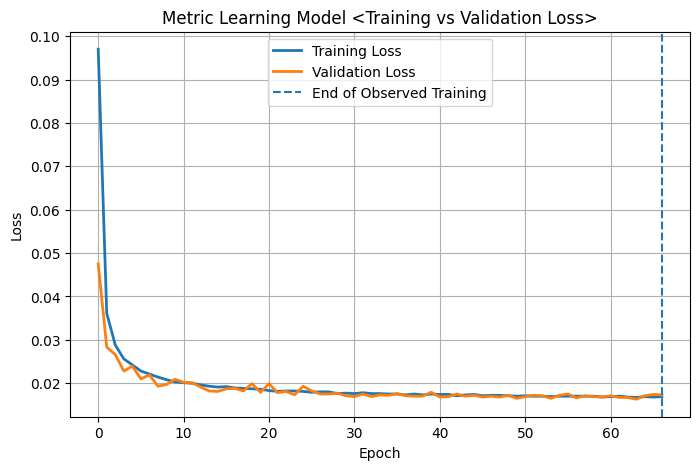

In [ ]:
import matplotlib.pyplot as plt

train_losses_str = """
0.0970
0.0361
0.0288
0.0256
0.0242
0.0228
0.0221
0.0214
0.0208
0.0203
0.0201
0.0200
0.0196
0.0193
0.0191
0.0192
0.0189
0.0188
0.0187
0.0186
0.0183
0.0181
0.0182
0.0182
0.0181
0.0179
0.0180
0.0180
0.0176
0.0177
0.0176
0.0178
0.0176
0.0176
0.0175
0.0175
0.0173
0.0175
0.0173
0.0175
0.0174
0.0174
0.0171
0.0173
00.0174
0.0171
0.0172
0.0172
0.0171
0.0170
0.0171
0.0170
0.0170
0.0169
0.0170
0.0170
0.0170
0.0170
0.0170
0.0168
0.0169
0.0170
0.0168
0.0167
0.0169
0.0168
0.0169
"""

val_losses_str = """
0.0475
0.0283
0.0266
0.0228
0.0239
0.0210
0.0219
0.0193
0.0197
0.0209
0.0202
0.0201
0.0191
0.0182
0.0181
0.0187
0.0188
0.0182
0.0199
0.0179
0.0199
0.0178
0.0181
0.0173
0.0193
0.0182
0.0175
0.0175
0.0177
0.0171
0.0169
0.0175
0.0169
0.0173
0.0172
0.0176
0.0171
0.0170
0.0170
0.0179
0.0168
0.0169
0.0175
0.0170
0.0172
0.0168
0.0170
0.0168
0.0172
0.0165
0.0169
0.0172
0.0171
0.0165
0.0172
0.0175
0.0166
0.0171
0.0169
0.0168
0.0171
0.0167
0.0167
0.0163
0.0171
0.0174
0.0173
"""

train_losses = [float(loss) for loss in train_losses_str.strip().split('\n')]
val_losses = [float(loss) for loss in val_losses_str.strip().split('\n')]

stop_epoch = len(train_losses) # The logging provided ends at epoch 67

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)

# Based on the logs, the training ran for 67 epochs, and early stopping was not triggered.
# The 'stop_epoch' here marks the end of the observed training run.
plt.axvline(x=stop_epoch - 1, linestyle="--", label="End of Observed Training")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Metric Learning Model <Training vs Validation Loss>")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import torch
import numpy as np
from scipy.spatial.distance import cosine, euclidean

device = "cuda" if torch.cuda.is_available() else "cpu"

model = PhoneticEncoder(FEATURE_DIM,
        hidden_dim=256,
        emb_dim=128)
model.load_state_dict(torch.load("/content/sanskrit_metric_learning_model.pkl", map_location=device))
model.to(device)
model.eval()


In [ ]:
def get_embedding(word):
    word = normalize_word(word)
    phonemes = words_to_phonemes(word)

    features = phonemes_to_features(phonemes, phoneme2vec)
    if features is None:
        raise ValueError(f"Unknown phoneme in word: {word}")

    x = torch.tensor(features).unsqueeze(0).float()  # (1, T, F)
    lengths = torch.tensor([x.shape[1]])

    with torch.no_grad():
        emb = model(x.to(device), lengths.to(device))

    return emb.squeeze(0).cpu().numpy()

In [ ]:
def compare_words(word1, word2):
    e1 = get_embedding(word1)
    e2 = get_embedding(word2)

    cos_dist = cosine(e1, e2)
    euc_dist = euclidean(e1, e2)

    return {
        "word1": word1,
        "word2": word2,
        "cosine_distance": float(cos_dist),
        "euclidean_distance": float(euc_dist)
    }


word_pairs = [
    ("माबि", "माभीभ"),
    ("इहैधि", "यहेधी"),
    ("इषुरि", "इशूरी"),
    ("उदेणी", "उधेनि"),
    ("इयमन्", "यमन्त"),
    ("नवप्", "प्राण"),
    ("कुल", "कूल"),
    ("सित", "सीता"),
    ("दिन", "दीन"),
    ("आसन", "आसन्न"),
    ("प्रवाह", "पर्वाह"),
    ("कर्म", "क्रम"),
    ("ग्रह", "गृह"),
    ("येवकं", "ऐवकं"),
    ("विश्पतिं", "विस्पंति")




]

In [ ]:
word_pairs = [
    ("माबि", "माभीभ"),
    ("इहैधि", "यहेधी"),
    ("इषुरि", "इशूरी"),
    ("उदेणी", "उधेनि"),
    ("इयमन्", "यमन्त"),
    ("नवप्", "प्राण"),
    ("कुल", "कूल"),
    ("सित", "सीता"),
    ("दिन", "दीन"),
    ("आसन", "आसन्न"),
    ("प्रवाह", "पर्वाह"),
    ("कर्म", "क्रम"),
    ("ग्रह", "गृह"),
    ("येवकं", "ऐवकं"),
    ("विश्पतिं", "विस्पंति")
]

results = []
for word1, word2 in word_pairs:
    try:
        results.append(compare_words(word1, word2))
    except ValueError as e:
        results.append({"word1": word1, "word2": word2, "error": str(e)})

for res in results:
    if "error" in res:
        print(f"{res['word1']} - {res['word2']} | Error: {res['error']}")
    else:
        print(f"{res['word1']} - {res['word2']} | Euclidean distance: {res['euclidean_distance']:.4f} | Cosine distance: {res['cosine_distance']:.4f}")

epochs = 63, patience = 10
* माबि - माभीभ | Euclidean distance: 1.6518 | Cosine distance: 0.1964
* इहैधि - यहेधी | Euclidean distance: 1.1449 | Cosine distance: 0.0806
* इषुरि - इशूरी | Euclidean distance: 0.2620 | Cosine distance: 0.0044
* उदेणी - उधेनि | Euclidean distance: 0.2912 | Cosine distance: 0.0052
* इयमन् - यमन्त | Euclidean distance: 0.8898 | Cosine distance: 0.1030
* नवप् - प्राण | Euclidean distance: 1.4128 | Cosine distance: 0.2879


epochs = 65, patience = 10
* माबि - माभीभ | Euclidean distance: 1.7086 | Cosine distance: 0.1065
* इहैधि - यहेधी | Euclidean distance: 1.1666 | Cosine distance: 0.0596
* इषुरि - इशूरी | Euclidean distance: 0.2826 | Cosine distance: 0.0035
* उदेणी - उधेनि | Euclidean distance: 0.2655 | Cosine distance: 0.0031
* इयमन् - यमन्त | Euclidean distance: 0.8595 | Cosine distance: 0.0581
* नवप् - प्राण | Euclidean distance: 1.4725 | Cosine distance: 0.1685
* कुल - कूल | Euclidean distance: 0.1413 | Cosine distance: 0.0027
* सित - सीता | Euclidean distance: 1.4937 | Cosine distance: 0.2517
* दिन - दीन | Euclidean distance: 0.1261 | Cosine distance: 0.0023
* आसन - आसन्न | Euclidean distance: 1.2780 | Cosine distance: 0.1295
* प्रवाह  - पर्वाह | Error: Unknown phoneme in word: पर्वाह
* कर्म - क्रम | Error: Unknown phoneme in word: कर्म
* ग्रह - गृह | Euclidean distance: 0.7757 | Cosine distance: 0.0816
* येवकं - ऐवकं | Euclidean distance: 1.6942 | Cosine distance: 0.1328
* विश्पतिं - विस्पंति | Euclidean distance: 1.2425 | Cosine distance: 0.0299

epochs = 41, patience = 10

* माबि - माभीभ | Euclidean distance: 1.7158 | Cosine distance: 0.2070
* इहैधि - यहेधी | Euclidean distance: 1.0519 | Cosine distance: 0.0746
* इषुरि - इशूरी | Euclidean distance: 0.1881 | Cosine distance: 0.0024
* उदेणी - उधेनि | Euclidean distance: 0.2430 | Cosine distance: 0.0041
* इयमन् - यमन्त | Euclidean distance: 0.8629 | Cosine distance: 0.0485
* नवप् - प्राण | Euclidean distance: 1.6558 | Cosine distance: 0.1931
* कुल - कूल | Euclidean distance: 0.1263 | Cosine distance: 0.0044
* सित - सीता | Euclidean distance: 1.4579 | Cosine distance: 0.3942
* दिन - दीन | Euclidean distance: 0.1225 | Cosine distance: 0.0054
* आसन - आसन्न | Euclidean distance: 2.3164 | Cosine distance: 0.4612
* प्रवाह - पर्वाह | Euclidean distance: 0.2745 | Cosine distance: 0.0027
* कर्म - क्रम | Euclidean distance: 0.2212 | Cosine distance: 0.0059
* ग्रह - गृह | Euclidean distance: 1.6990 | Cosine distance: 0.4086
* येवकं - ऐवकं | Euclidean distance: 1.6812 | Cosine distance: 0.2187
* विश्पतिं - विस्पंति | Euclidean distance: 1.1582 | Cosine distance: 0.0218

epochs = 50, patience = 10

* माबि - माभीभ | Euclidean distance: 1.6297 | Cosine distance: 0.1516
* इहैधि - यहेधी | Euclidean distance: 1.2087 | Cosine distance: 0.0804
* इषुरि - इशूरी | Euclidean distance: 0.2785 | Cosine distance: 0.0040
* उदेणी - उधेनि | Euclidean distance: 0.3042 | Cosine distance: 0.0049
* इयमन् - यमन्त | Euclidean distance: 0.8180 | Cosine distance: 0.0344
* नवप् - प्राण | Euclidean distance: 1.6783 | Cosine distance: 0.1652
* कुल - कूल | Euclidean distance: 0.1502 | Cosine distance: 0.0047
* सित - सीता | Euclidean distance: 1.4955 | Cosine distance: 0.2885
* दिन - दीन | Euclidean distance: 0.1186 | Cosine distance: 0.0032
* आसन - आसन्न | Euclidean distance: 2.2988 | Cosine distance: 0.3026
* प्रवाह - पर्वाह | Euclidean distance: 0.3187 | Cosine distance: 0.0032
* कर्म - क्रम | Euclidean distance: 0.1876 | Cosine distance: 0.0033
* ग्रह - गृह | Euclidean distance: 1.7208 | Cosine distance: 0.3491
* येवकं - ऐवकं | Euclidean distance: 1.5913 | Cosine distance: 0.1478
* विश्पतिं - विस्पंति | Euclidean distance: 1.2122 | Cosine distance: 0.0207

In [ ]:
def word_to_articulatory_sequence(word):
    word = normalize_word(word)
    phonemes = words_to_phonemes(word)

    seq = []
    for p in phonemes:
        if p not in phoneme2vec:
            raise ValueError(f"Unknown phoneme: {p}")
        seq.append(phoneme2vec[p])

    return seq


In [ ]:
def articulatory_word_distance(word1, word2):
    seq1 = word_to_articulatory_sequence(word1)
    seq2 = word_to_articulatory_sequence(word2)
    return articulatory_distance(seq1, seq2)


In [ ]:
def articulatory_distance_for_pairs(word_pairs):
    results = []

    for w1, w2 in word_pairs:
        try:
            dist = articulatory_word_distance(w1, w2)
            results.append({
                "word1": w1,
                "word2": w2,
                "articulatory_distance": dist
            })
        except Exception as e:
            results.append({
                "word1": w1,
                "word2": w2,
                "articulatory_distance": None,
                "error": str(e)
            })

    return results


In [ ]:
def print_articulatory_results(results):
    for res in results:
        if res["articulatory_distance"] is not None:
            print(
                f"{res['word1']} - {res['word2']} | "
                f"Articulatory distance: {res['articulatory_distance']:.4f}"
            )
        else:
            print(
                f"{res['word1']} - {res['word2']} | "
                f"FAILED ({res.get('error', 'unknown error')})"
            )


In [ ]:
# word_pairs = [
#     ("माबि", "माभीभ"),
#     ("इहैधि", "यहेधी"),
#     ("इषुरि", "इशूरी"),
#     ("उदेणी", "उधेनि"),
#     ("इयमन्", "यमन्त"),
#     ("नवप्", "प्राण")
# ]

results = articulatory_distance_for_pairs(word_pairs)
print_articulatory_results(results)


* माबि - माभीभ | Articulatory distance: 1.1176
* इहैधि - यहेधी | Articulatory distance: 0.8824
* इषुरि - इशूरी | Articulatory distance: 0.1765
* उदेणी - उधेनि | Articulatory distance: 0.1765
* इयमन् - यमन्त | Articulatory distance: 0.8235
* नवप् - प्राण | Articulatory distance: 1.5294